# Token Pipeline Inspector

Set a `SEQUENCE`, run it, and watch the effect on `State` at each step: what
each token **takes** (its resolved inputs) and its **impact** (new/changed
features, board signals, scale/transform changes, prediction + residual).

All machinery lives in `pipeline_inspect.py` — this notebook is just config and
calls.


## Setup

In [1]:
from pathlib import Path
import sys
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
try:
    from tqdm.auto import tqdm
except Exception:
    def tqdm(x, **k):
        return x
warnings.filterwarnings('default')
%matplotlib inline

HERE = Path.cwd().resolve()
for root in [HERE, HERE.parent, HERE.parent.parent]:
    if (root / "graph_Time_series" / "state.py").exists():
        PACKAGE_ROOT = root; break
    if (root / "graph_Time_series" / "graph_Time_series" / "state.py").exists():
        PACKAGE_ROOT = root / "graph_Time_series"; break
else:
    raise FileNotFoundError("Could not locate the graph_Time_series package checkout.")
sys.path.insert(0, str(PACKAGE_ROOT))
sys.path.insert(0, str(PACKAGE_ROOT / "examples"))
sys.path.insert(0, str(HERE))

from pipeline_inspect import (
    inspect_pipeline, build_grammar, token_table,
    summarize_state, signal_board_df, feature_bundle_df, artifact_df,
    plot_raw_data, plot_array_artifact, plot_prediction_state, score_prediction,
)

grammar = build_grammar()
print(grammar)


c:\Users\chahine\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Grammar(19 tokens, 53 edges)


## Data

Produce `H` (history) and `F` (future) arrays of shape `(n_samples, length)`.

In [2]:
HISTORY_LENGTH = 3_000
HORIZON = 700
SEASONAL_PERIOD = 48
SEED = 7

# Data source options: "pretrain_extracted_chunks", "pretrain_sliding_from_extracted", "manual_series", "synthetic".
DATA_SOURCE = "pretrain_extracted_chunks"

# Local pretrain shards created by nested loops/pretrain_chunk_builder.ipynb.
PRETRAIN_RUN_DIR = (
    PACKAGE_ROOT.parent
    / "nested loops"
    / "pretrain_extracted_shards"
    / "GiftEvalPretrain__Energy-Transport__20260607_154145"
)
PRETRAIN_TAG_CONTAINS = "Energy__"  # use "australian_electricity_demand" for one subset, or "" for all shards
PRETRAIN_MAX_RECORDS = None          # None = all records matching PRETRAIN_TAG_CONTAINS
PRETRAIN_SERIES_MODE = "history_plus_future"  # only used by pretrain_sliding_from_extracted

# Sliding-window construction, only used by manual_series or pretrain_sliding_from_extracted.
SLIDING_STRIDE = HORIZON
MAX_WINDOWS_TOTAL = None
MAX_WINDOWS_PER_SOURCE_SERIES = None
DROP_SHORT_SERIES = True

# Manual series mode. Set DATA_SOURCE = "manual_series" and assign SERIES.
# Example: SERIES = np.asarray(my_dataframe["value"].values, dtype=np.float32)
SERIES = None

def clean_1d_series(values):
    values = np.asarray(values, dtype=np.float32).reshape(-1).copy()
    if values.size == 0:
        return values
    finite = np.isfinite(values)
    if np.all(finite):
        return values
    if not np.any(finite):
        return np.zeros_like(values, dtype=np.float32)
    idx = np.arange(values.size)
    values[~finite] = np.interp(idx[~finite], idx[finite], values[finite]).astype(np.float32)
    return values

def sliding_windows_from_series(series, *, history_len, horizon, stride, max_windows=None, meta=None):
    series = clean_1d_series(series)
    needed = history_len + horizon
    if series.size < needed:
        if DROP_SHORT_SERIES:
            return []
        raise ValueError(f"Series has {series.size} points, need at least {needed}.")
    starts = range(0, series.size - needed + 1, max(int(stride), 1))
    windows = []
    for local_idx, start in enumerate(starts):
        if max_windows is not None and local_idx >= max_windows:
            break
        end_h = start + history_len
        end_f = end_h + horizon
        windows.append({
            "history": series[start:end_h].astype(np.float32, copy=True),
            "future": series[end_h:end_f].astype(np.float32, copy=True),
            "window_start": int(start),
            "window_end": int(end_f),
            **(meta or {}),
        })
    return windows

def load_pretrain_records(run_dir, tag_contains="", max_records=None):
    run_dir = Path(run_dir)
    manifest_path = run_dir / "shard_manifest.csv"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing shard manifest: {manifest_path}")
    manifest = pd.read_csv(manifest_path)
    if tag_contains:
        mask = manifest["tag"].astype(str).str.contains(tag_contains, case=False, regex=False)
        manifest = manifest[mask].copy()
    if manifest.empty:
        raise ValueError(f"No pretrain shards matched tag_contains={tag_contains!r} in {manifest_path}")

    records = []
    selected_rows = []
    for _, row in tqdm(manifest.iterrows(), total=len(manifest), desc="loading pretrain shards"):
        shard_path = Path(row["path"])
        if not shard_path.exists():
            shard_path = run_dir / "extracted_chunks" / shard_path.name
        with shard_path.open("rb") as f:
            shard_records = pickle.load(f)
        for rec in shard_records:
            records.append(rec)
            selected_rows.append(row.to_dict())
            if max_records is not None and len(records) >= max_records:
                return records, pd.DataFrame(selected_rows)
    return records, pd.DataFrame(selected_rows)

def pretrain_record_to_series(record, mode="history_plus_future"):
    history = clean_1d_series(record.get("history", []))
    future = clean_1d_series(record.get("future", []))
    if mode == "history_only":
        return history
    if mode == "future_only":
        return future
    if mode == "history_plus_future":
        return np.concatenate([history, future]).astype(np.float32)
    raise ValueError("PRETRAIN_SERIES_MODE must be history_only, future_only, or history_plus_future")

def build_dataset_from_pretrain_extracted_chunks():
    records, selected_manifest = load_pretrain_records(
        PRETRAIN_RUN_DIR,
        tag_contains=PRETRAIN_TAG_CONTAINS,
        max_records=PRETRAIN_MAX_RECORDS,
    )
    rows, histories, futures = [], [], []
    for record_idx, rec in enumerate(tqdm(records, desc="stacking extracted chunks")):
        history = clean_1d_series(rec.get("history", []))
        future = clean_1d_series(rec.get("future", []))
        if HISTORY_LENGTH is not None and history.size != HISTORY_LENGTH:
            continue
        if HORIZON is not None and future.size != HORIZON:
            continue
        histories.append(history.astype(np.float32, copy=True))
        futures.append(future.astype(np.float32, copy=True))
        rows.append({
            "source": "pretrain_extracted_chunks",
            "record_idx": record_idx,
            "sample_idx": rec.get("sample_idx"),
            "source_domain": rec.get("source_domain"),
            "source_subset": rec.get("source_subset"),
            "source_row_idx": rec.get("source_row_idx"),
            "item_id": rec.get("item_id"),
            "freq": rec.get("freq"),
            "chunk_start": rec.get("chunk_start"),
            "history_len": int(history.size),
            "future_len": int(future.size),
            "source_length": rec.get("source_length"),
            "history_missing_fraction": rec.get("history_missing_fraction"),
            "future_missing_fraction": rec.get("future_missing_fraction"),
        })
    if not histories:
        raise ValueError("No extracted chunks matched the selected length/filter settings.")
    return (
        np.stack(histories).astype(np.float32),
        np.stack(futures).astype(np.float32),
        pd.DataFrame(rows),
        selected_manifest,
    )

def build_windows_from_pretrain_shards():
    records, selected_manifest = load_pretrain_records(
        PRETRAIN_RUN_DIR,
        tag_contains=PRETRAIN_TAG_CONTAINS,
        max_records=PRETRAIN_MAX_RECORDS,
    )
    all_windows = []
    iterator = tqdm(records, desc="cutting sliding windows")
    for record_idx, rec in enumerate(iterator):
        series = pretrain_record_to_series(rec, PRETRAIN_SERIES_MODE)
        meta = {
            "source": "pretrain_shard",
            "record_idx": record_idx,
            "sample_idx": rec.get("sample_idx"),
            "source_domain": rec.get("source_domain"),
            "source_subset": rec.get("source_subset"),
            "source_row_idx": rec.get("source_row_idx"),
            "item_id": rec.get("item_id"),
            "freq": rec.get("freq"),
            "series_len": int(series.size),
        }
        windows = sliding_windows_from_series(
            series,
            history_len=HISTORY_LENGTH,
            horizon=HORIZON,
            stride=SLIDING_STRIDE,
            max_windows=MAX_WINDOWS_PER_SOURCE_SERIES,
            meta=meta,
        )
        all_windows.extend(windows)
        iterator.set_postfix(windows=len(all_windows))
        if MAX_WINDOWS_TOTAL is not None and len(all_windows) >= MAX_WINDOWS_TOTAL:
            all_windows = all_windows[:MAX_WINDOWS_TOTAL]
            break
    if not all_windows:
        raise ValueError("No sliding windows were created from the selected pretrain records.")
    H_arr = np.stack([w["history"] for w in all_windows]).astype(np.float32)
    F_arr = np.stack([w["future"] for w in all_windows]).astype(np.float32)
    meta_df = pd.DataFrame([{k: v for k, v in w.items() if k not in {"history", "future"}} for w in all_windows])
    return H_arr, F_arr, meta_df, selected_manifest

def make_synthetic_data(n_samples=8, hist_len=HISTORY_LENGTH, horizon=HORIZON, period=SEASONAL_PERIOD, seed=SEED):
    rng = np.random.default_rng(seed)
    t_hist = np.arange(hist_len)
    t_future = np.arange(hist_len, hist_len + horizon)
    histories, futures = [], []
    for i in range(n_samples):
        level = 10.0 + 0.6 * i
        amp = 2.2 + 0.2 * np.sin(i)
        trend = 0.01 * (i + 1)
        hist = (
            level
            + trend * t_hist
            + amp * np.sin(2 * np.pi * t_hist / period)
            + 0.6 * np.cos(2 * np.pi * t_hist / 7)
            + rng.normal(0, 0.25, hist_len)
        )
        fut = (
            level
            + trend * t_future
            + amp * np.sin(2 * np.pi * t_future / period)
            + 0.6 * np.cos(2 * np.pi * t_future / 7)
        )
        histories.append(hist)
        futures.append(fut)
    return np.asarray(histories, np.float32), np.asarray(futures, np.float32)

if DATA_SOURCE == "pretrain_extracted_chunks":
    H, F, WINDOW_META, PRETRAIN_SELECTED_MANIFEST = build_dataset_from_pretrain_extracted_chunks()
elif DATA_SOURCE == "pretrain_sliding_from_extracted":
    H, F, WINDOW_META, PRETRAIN_SELECTED_MANIFEST = build_windows_from_pretrain_shards()
elif DATA_SOURCE == "manual_series":
    if SERIES is None:
        raise ValueError("Set SERIES when DATA_SOURCE='manual_series'.")
    windows = sliding_windows_from_series(
        SERIES,
        history_len=HISTORY_LENGTH,
        horizon=HORIZON,
        stride=SLIDING_STRIDE,
        max_windows=MAX_WINDOWS_TOTAL,
        meta={"source": "manual_series"},
    )
    H = np.stack([w["history"] for w in windows]).astype(np.float32)
    F = np.stack([w["future"] for w in windows]).astype(np.float32)
    WINDOW_META = pd.DataFrame([{k: v for k, v in w.items() if k not in {"history", "future"}} for w in windows])
    PRETRAIN_SELECTED_MANIFEST = pd.DataFrame()
elif DATA_SOURCE == "synthetic":
    H, F = make_synthetic_data(n_samples=min(MAX_WINDOWS_TOTAL or 8, 64))
    WINDOW_META = pd.DataFrame({"source": ["synthetic"] * H.shape[0], "record_idx": np.arange(H.shape[0])})
    PRETRAIN_SELECTED_MANIFEST = pd.DataFrame()
else:
    raise ValueError("DATA_SOURCE must be pretrain_extracted_chunks, pretrain_sliding_from_extracted, manual_series, or synthetic")

print("DATA_SOURCE", DATA_SOURCE)
print("H", H.shape, "F", F.shape)
if not PRETRAIN_SELECTED_MANIFEST.empty:
    display(PRETRAIN_SELECTED_MANIFEST.drop_duplicates("path").head(10))
display(WINDOW_META.head(12))
pd.DataFrame({"history_first_sample": H[0], "future_first_sample": np.r_[F[0], np.full(max(H.shape[1] - F.shape[1], 0), np.nan)[:H.shape[1]]] if F.shape[1] <= H.shape[1] else H[0]}).head()

stacking extracted chunks: 100%|██████████| 677/677 [00:00<00:00, 27871.73it/s]

DATA_SOURCE pretrain_extracted_chunks
H (677, 3000) F (677, 700)


,first_sample_idx,kind,last_sample_idx,n_records,path,shard_idx,tag
0,0,extracted_chunks,49,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__australian_electricity_demand
50,50,extracted_chunks,59,10,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__covid19_energy
60,60,extracted_chunks,64,5,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__elecdemand
65,65,extracted_chunks,71,7,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__elf
72,72,extracted_chunks,76,5,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__gfc14_load
77,77,extracted_chunks,126,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__largest_2017
127,127,extracted_chunks,176,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__largest_2018
177,177,extracted_chunks,226,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__largest_2019
227,227,extracted_chunks,276,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__largest_2020
277,277,extracted_chunks,326,50,C:\Users\chahine\Desktop\stage\nested loops\pr...,0,Energy__largest_2021


,source,record_idx,sample_idx,source_domain,source_subset,source_row_idx,item_id,freq,chunk_start,history_len,future_len,source_length,history_missing_fraction,future_missing_fraction
0,pretrain_extracted_chunks,0,0,Energy,australian_electricity_demand,0,T1,30T,0,3000,700,230400,0.0,0.0
1,pretrain_extracted_chunks,1,1,Energy,australian_electricity_demand,0,T1,30T,3000,3000,700,230400,0.0,0.0
2,pretrain_extracted_chunks,2,2,Energy,australian_electricity_demand,0,T1,30T,6000,3000,700,230400,0.0,0.0
3,pretrain_extracted_chunks,3,3,Energy,australian_electricity_demand,0,T1,30T,9000,3000,700,230400,0.0,0.0
4,pretrain_extracted_chunks,4,4,Energy,australian_electricity_demand,0,T1,30T,12000,3000,700,230400,0.0,0.0
5,pretrain_extracted_chunks,5,5,Energy,australian_electricity_demand,0,T1,30T,15000,3000,700,230400,0.0,0.0
6,pretrain_extracted_chunks,6,6,Energy,australian_electricity_demand,0,T1,30T,18000,3000,700,230400,0.0,0.0
7,pretrain_extracted_chunks,7,7,Energy,australian_electricity_demand,0,T1,30T,21000,3000,700,230400,0.0,0.0
8,pretrain_extracted_chunks,8,8,Energy,australian_electricity_demand,0,T1,30T,24000,3000,700,230400,0.0,0.0
9,pretrain_extracted_chunks,9,9,Energy,australian_electricity_demand,0,T1,30T,27000,3000,700,230400,0.0,0.0


,history_first_sample,future_first_sample
0,5714.044922,7519.589844
1,5360.188965,7509.793457
2,5014.834961,7515.182617
3,4602.755371,7463.664551
4,4285.179688,7431.477051


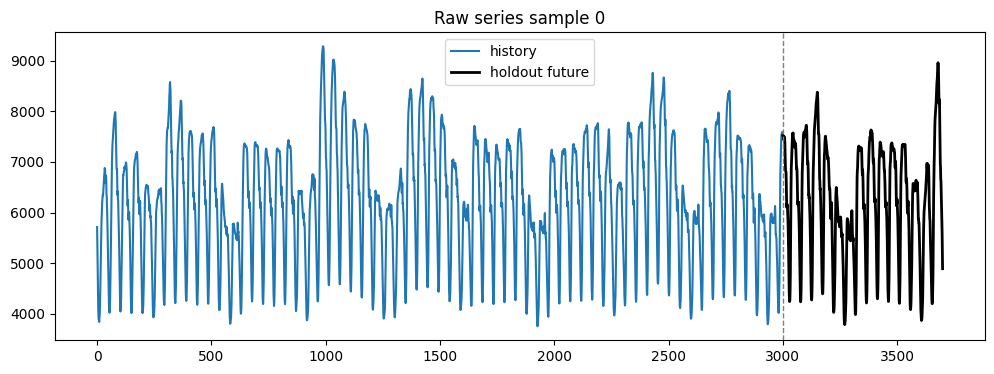

In [3]:
plot_raw_data(H, F, sample_idx=0)

## Choose a pipeline
1 ZNormalization → kernel_rbf    #works OK
2 MeanAbsScaling → rf_tabular    #works OK
3 ZNormalization → FourierFeatures → rf_tabular #actually better than 2 so this is good news
4 MeanAbsScaling → FourierFeatures → lightgbm_tabular # that s too long I think I ll drop the lightGBM
5 ZNormalization → PeriodDetect → SeasonalFeatures → step_regression  #ONLY WORKS IF WE DO HAVE PERIOD DETECT WHIHC IS GOOD
6 ZNormalization → PeriodDetect → SeasonalFeatures → rf_tabular #KIND OF DISAPPOINTED WOULD NEED MORE , but does what is asked of it correctly
7 ZNormalization → PeriodDetect → SeasonalFeatures → kernel_rbf #ACTUALLY WORKS rbf does not take the other tokens into account as it has no way of integrating them
8 FlairPreprocess -> PeriodDetect -> PeriodFold -> ShapeLevel -> SecondaryLevelSeasonality -> level_shape_ridge # compact level/shape ridge, minimal state
9 FlairPreprocess -> PeriodDetect -> PeriodFold -> ShapeLevel -> SecondaryLevelSeasonality -> LevelBoxCoxCenter -> FlairRidgeLevel # verbose inspection path
10 ZNormalization -> FourierFeatures -> rf_tabular -> versatile_gb

In [4]:
SEQUENCE = ["FlairPreprocess", "PeriodDetect", "PeriodFold", "ShapeLevel", "SecondaryLevelSeasonality", "level_shape_ridge"]

SAMPLE_IDX      = 0
SEASONAL_PERIOD = 48
PLOT_EACH_STEP  = True
SHOW_SIGNAL_BOARD = False
SHOW_FEATURE_BUNDLE = False


## Run the pipeline

Each token prints what it **takes** and its **impact** on `State`.

Running: FlairPreprocess -> PeriodDetect -> PeriodFold -> ShapeLevel -> SecondaryLevelSeasonality -> LevelBoxCoxCenter -> FlairRidgeLevel -> kernel_rbf
Initial valid next: ['ZNormalization', 'MeanAbsScaling', 'FourierFeatures', 'FlairPreprocess', 'PeriodDetect']


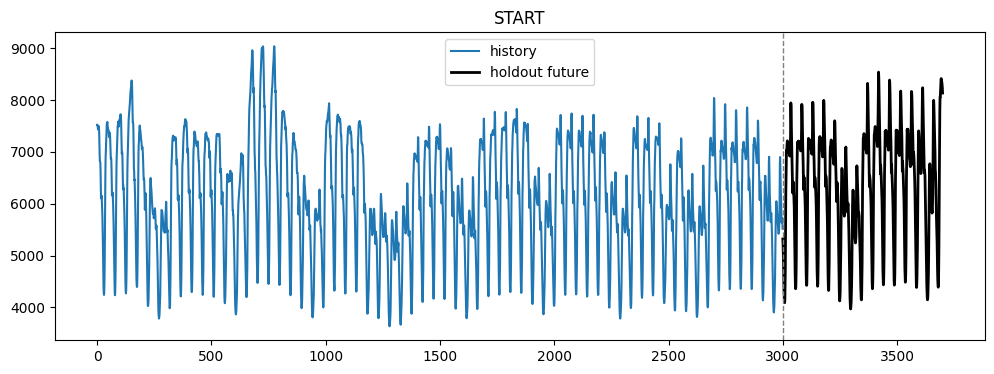


------------------------------------------------------------------------------
STEP 1  -  FlairPreprocess   [cleaning]
  FLAIR preprocessing: finite interpolation plus positivity shift.
  > TAKES:
      reads  raw_history  (677, 3000)  [features]
  > IMPACT on state:
      + historical_features: flair_history (677, 3000)
      + signal: flair_history  [series('sample', 'time') @flair_shift]
      space: raw -> flair_shift
      + transform(s): ['flair_shift']  (inverse auto-applied at decode)
      + flags: ['flair_preprocessed']
      + metadata: flair_shift = ndarray(677,)
  > valid next: ['PeriodDetect']


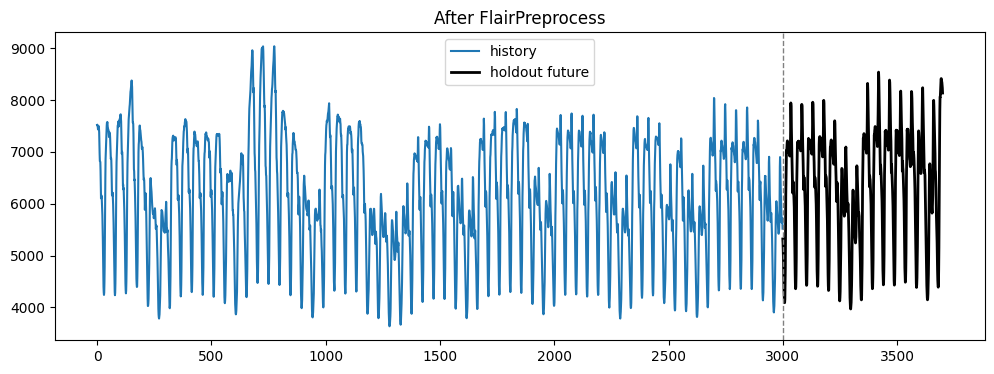

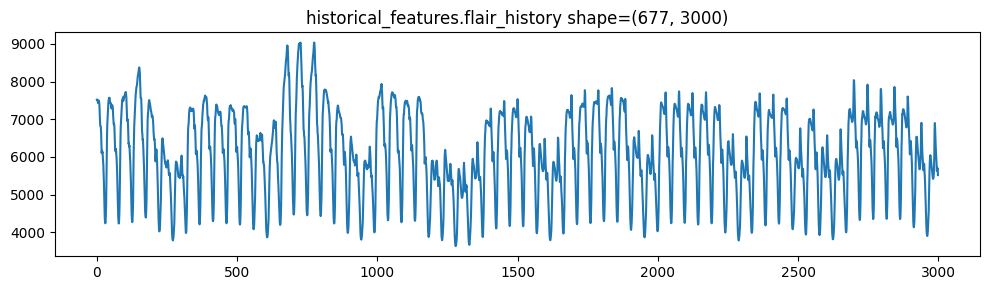


------------------------------------------------------------------------------
STEP 2  -  PeriodDetect   [feature]
  FLAIR-style BIC period selection (freq candidates) -> param:periods.
  > TAKES:
      reads  raw_history  (677, 3000)  [features]
  > IMPACT on state:
      + signal: param:periods  [param:periods() @raw] = [336]
      + flags: ['periods_detected']
      + metadata: flair_secondary_periods = []
      + metadata: period = 336
      + metadata: period_scores = {1: 42526.02593759289, 6: 38951.42668206706, 8: 39936.24363745716, 12: 39118.232331738036, 24: 41223.52224847913, 48: 35537.11121969756, 72: ...
      + metadata: periods = [336]
  > valid next: ['PeriodFold', 'SeasonalFeatures', 'step_regression']


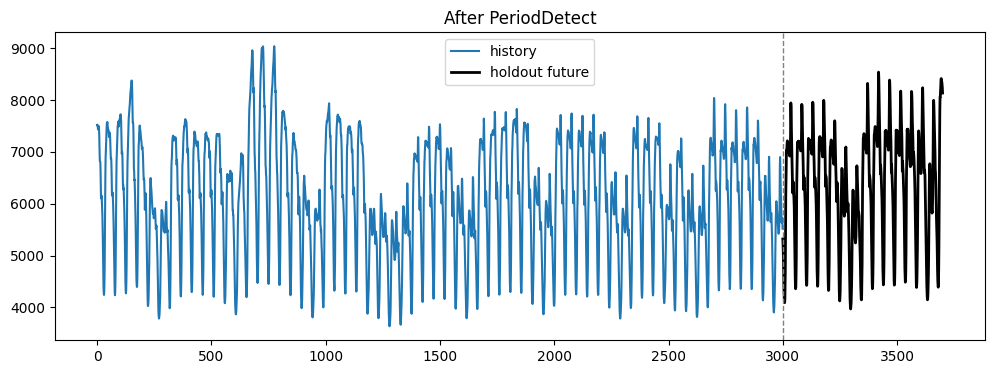

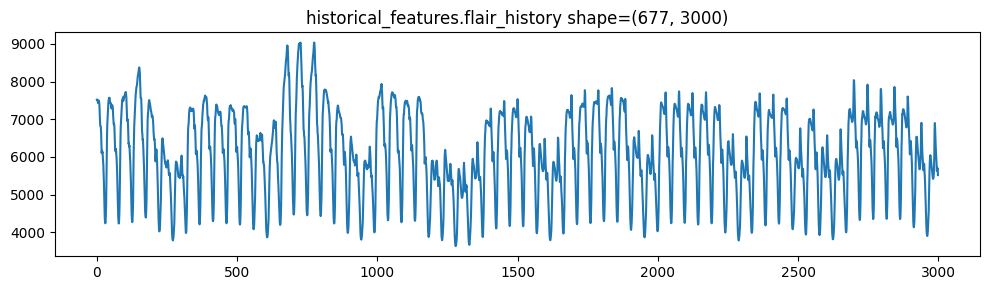


------------------------------------------------------------------------------
STEP 3  -  PeriodFold   [feature]
  Fold FLAIR history into period phases + level totals (optional SVD level shrink).
  > TAKES:
      reads  flair_history  (677, 3000)  [historical_features]
      reads  period  int  [metadata]
  > IMPACT on state:
      + historical_features: period_matrix (677, 336, 8)
      + historical_features: level_series (677, 8)
      + historical_features: flair_period_matrix (677, 336, 8)
      + historical_features: flair_level_raw (677, 8)
      + historical_features: flair_level_denoised (677, 8)
      + signal: flair_period_matrix  [features('sample', 'time', 'feature') @flair_shift]
      + signal: flair_level_raw  [features('sample', 'feature') @flair_shift]
      + signal: period_matrix  [series('sample', 'phase', 'period_idx') @flair_shift]
      + signal: level_series  [level('sample', 'period_idx') @flair_shift]
      + signal: flair_level_denoised  [level('sample', 'p

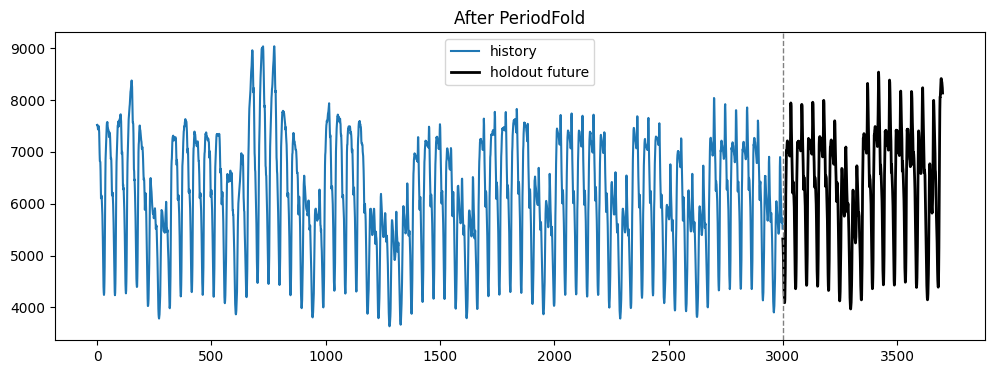

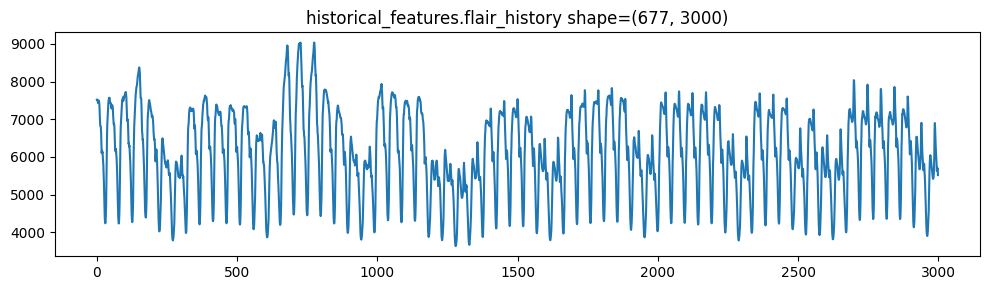

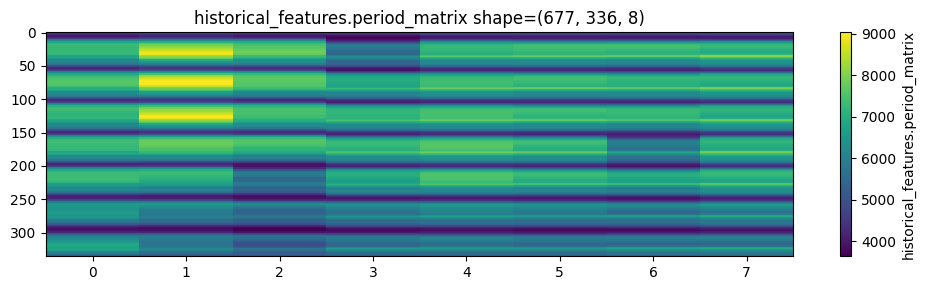

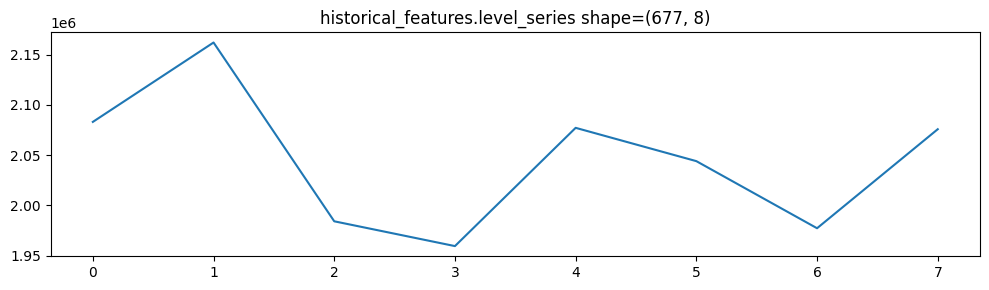

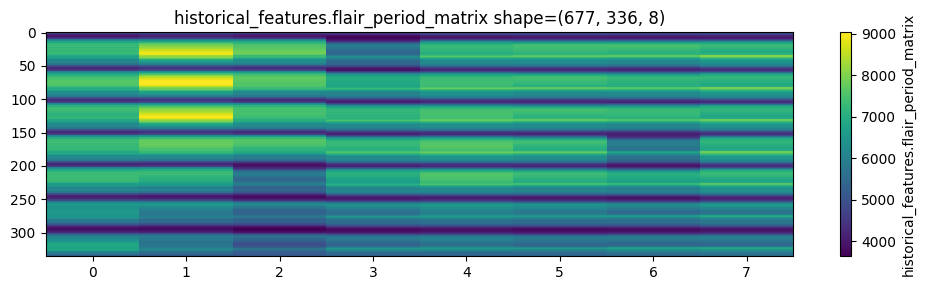

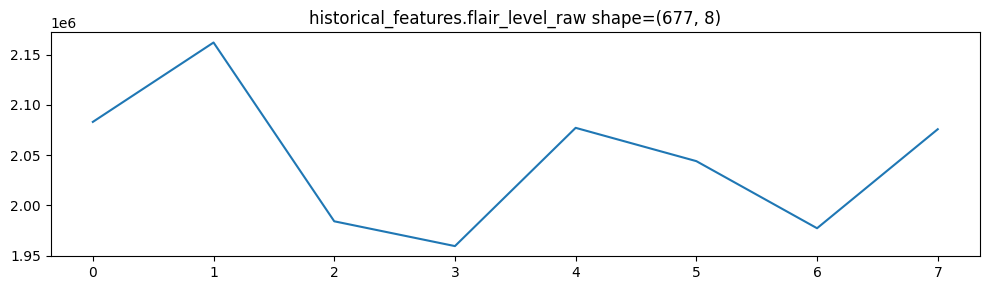

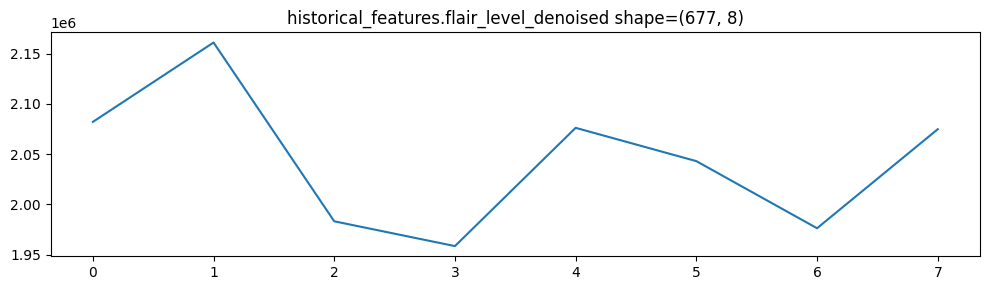


------------------------------------------------------------------------------
STEP 4  -  ShapeLevel   [feature]
  Estimate FLAIR within-period proportions from recent periods.
  > TAKES:
      reads  period_matrix  (677, 336, 8)  [historical_features]
      reads  level_series  (677, 8)  [historical_features]
  > IMPACT on state:
      + historical_features: shape_vector (677, 336)
      + historical_features: flair_shape (677, 336)
      + historical_features: flair_shape_history (677, 336, 8)
      + signal: flair_shape  [features('sample', 'feature') @flair_shift]
      + signal: flair_shape_history  [series('sample', 'time') @flair_shift]
      + signal: shape_vector  [shape('sample', 'phase') @flair_shift]
      + metadata: shape_k = 2
  > valid next: ['SecondaryLevelSeasonality', 'gb_level_forecast']


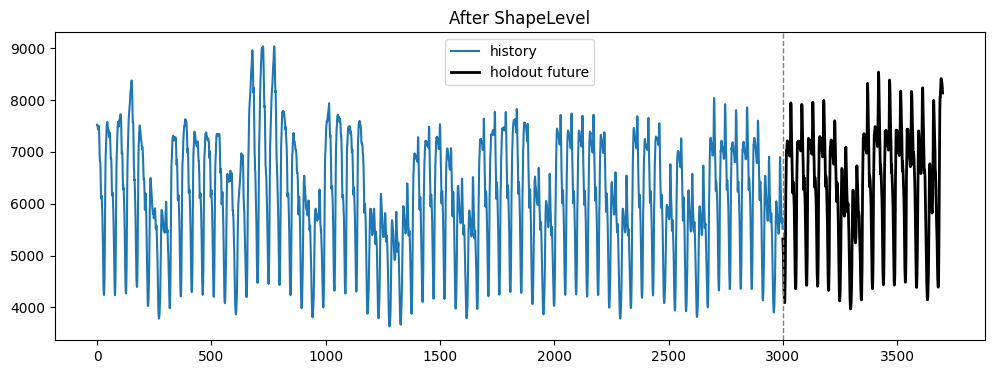

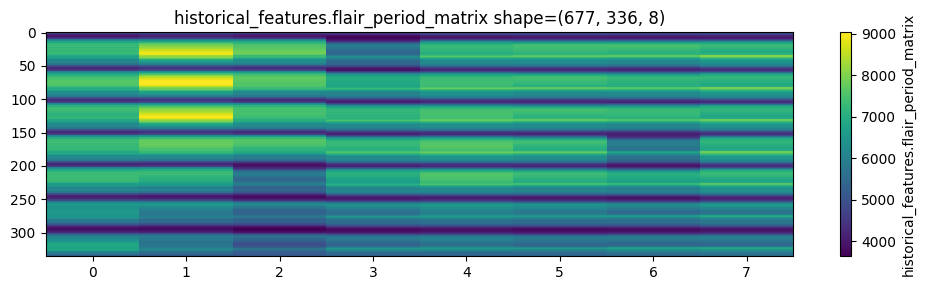

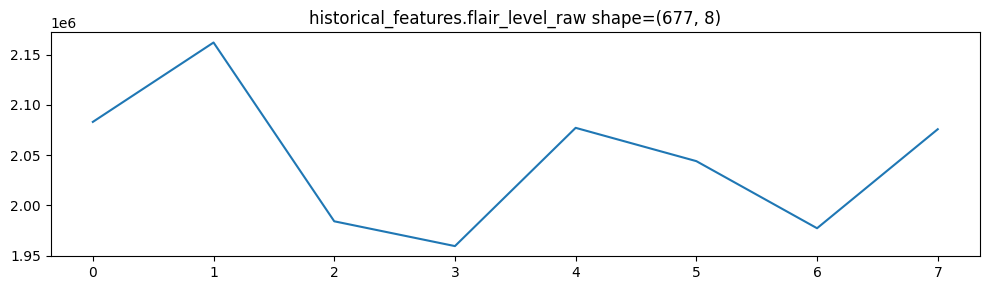

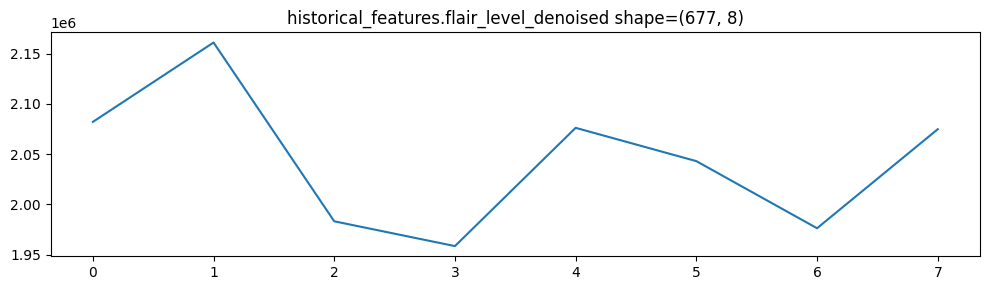

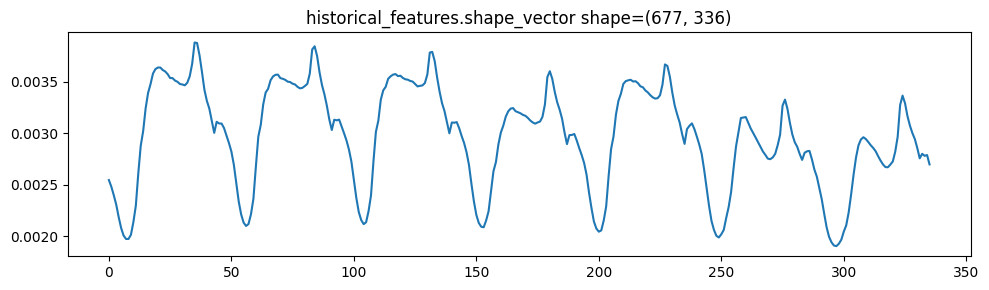

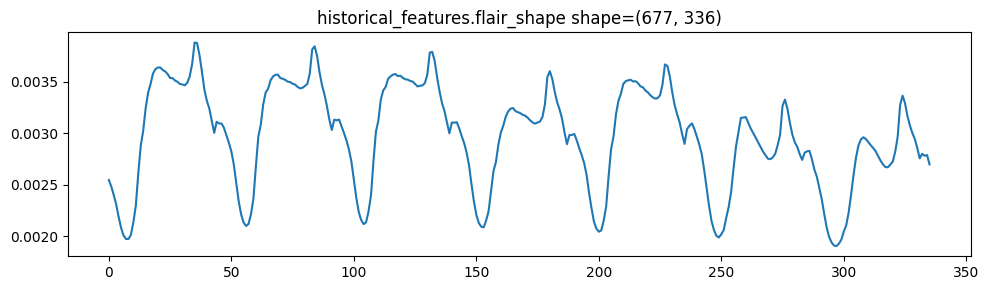

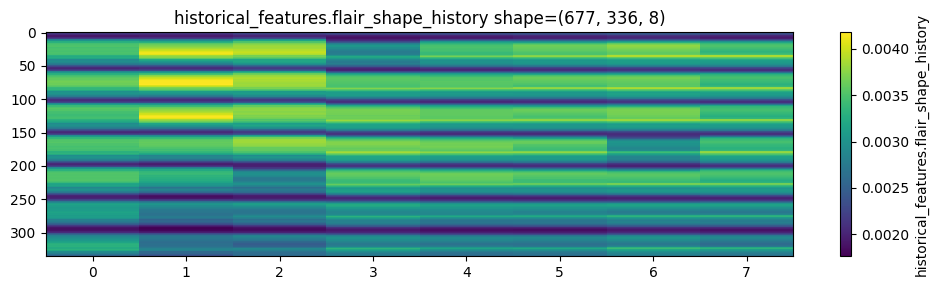


------------------------------------------------------------------------------
STEP 5  -  SecondaryLevelSeasonality   [feature]
  Estimate secondary FLAIR seasonality over period-level totals.
  > TAKES:
      reads  level_series  (677, 8)  [historical_features]
      reads  period  int  [metadata]
  > IMPACT on state:
      + historical_features: flair_shape2 (677, 1)
      + historical_features: flair_level_work (677, 8)
      + features: flair_level_future_shape2 (677, 3)
      + signal: flair_shape2  [features('sample', 'feature') @flair_shift]
      + signal: flair_level_work  [level('sample', 'period_idx') @flair_shift]
      + metadata: flair_cross_period = 1
      + metadata: flair_cross_periods = []
  > valid next: ['LevelBoxCoxCenter']


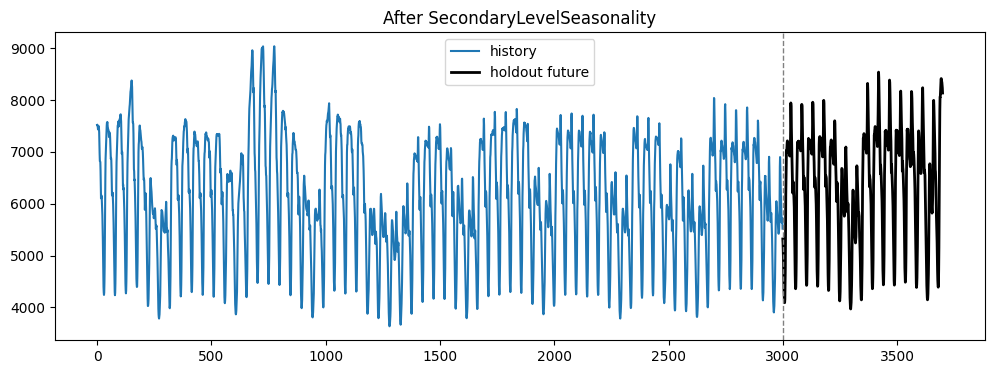

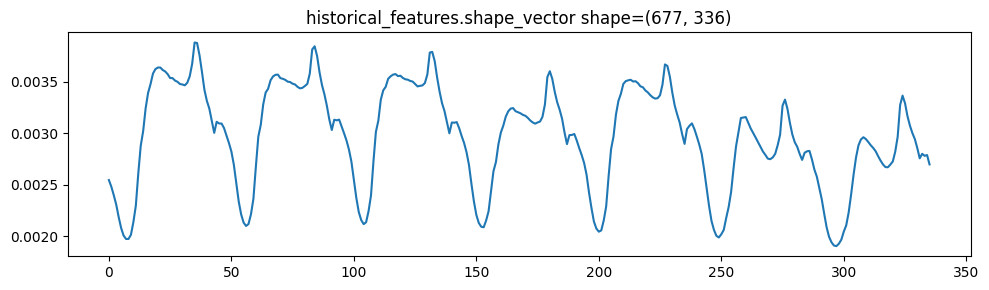

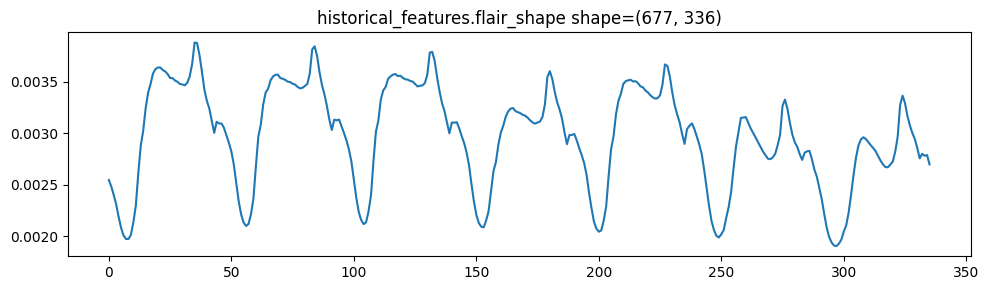

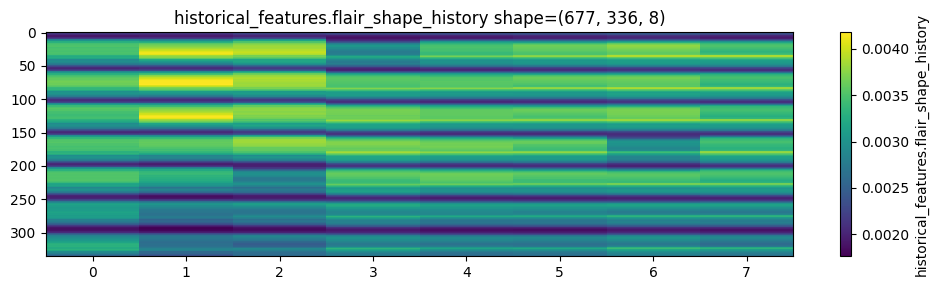

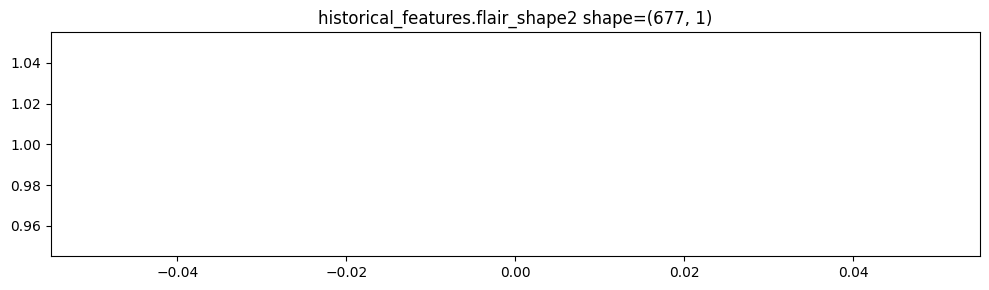

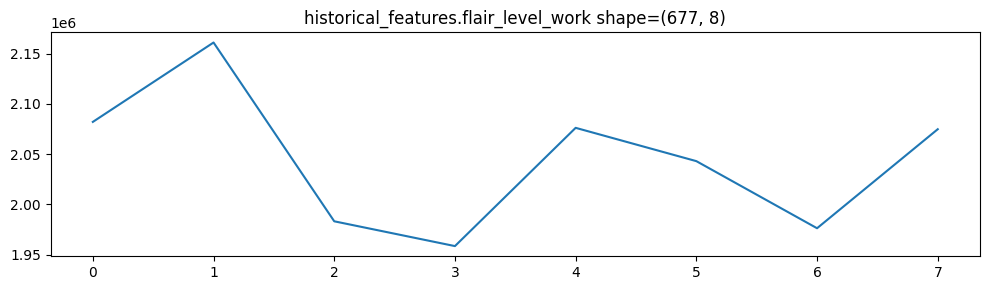

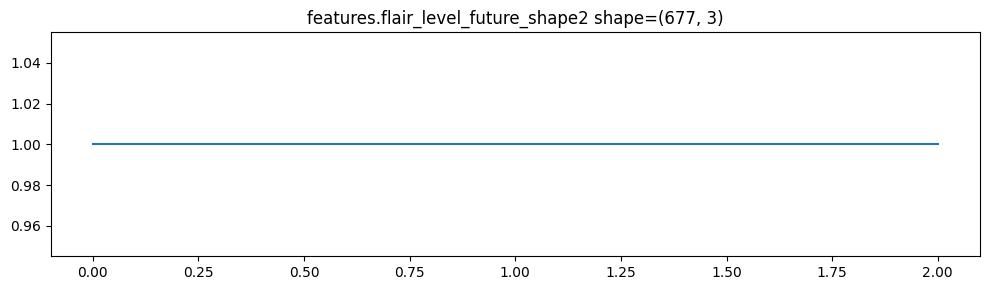


------------------------------------------------------------------------------
STEP 6  -  LevelBoxCoxCenter   [feature]
  Box-Cox transform FLAIR levels and center by the last level.
  > TAKES:
      reads  flair_level_work  (677, 8)  [historical_features]
  > IMPACT on state:
      + historical_features: flair_level_bc (677, 8)
      + historical_features: flair_level_innov (677, 8)
      + signal: flair_level_bc  [features('sample', 'feature') @flair_shift]
      + signal: flair_level_innov  [features('sample', 'feature') @flair_shift]
      + metadata: flair_boxcox = {'lambda': 'ndarray(677,)', 'offset': 'ndarray(677,)', 'last': 'ndarray(677,)'}
  > valid next: ['FlairRidgeLevel']


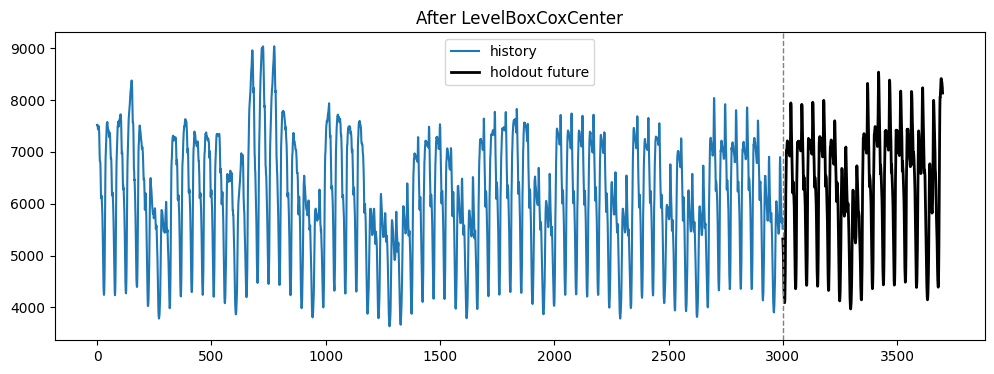

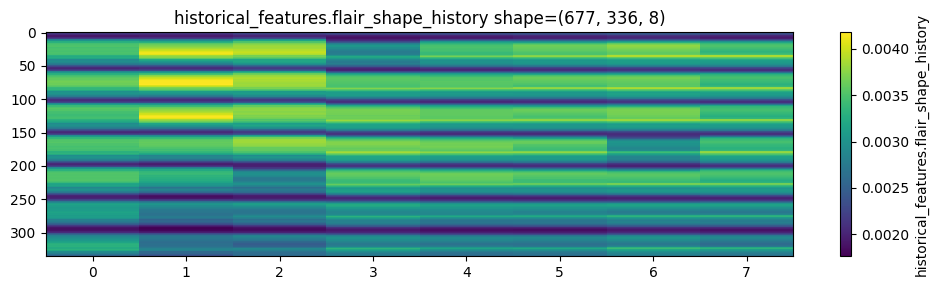

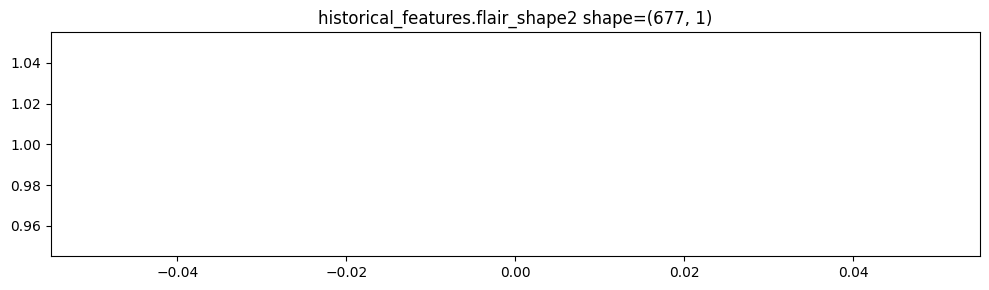

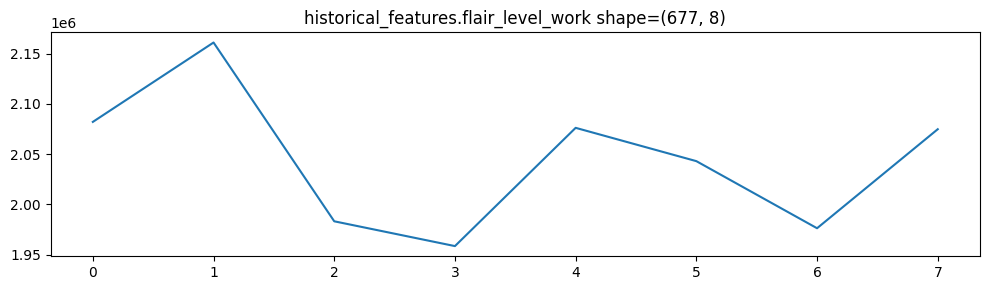

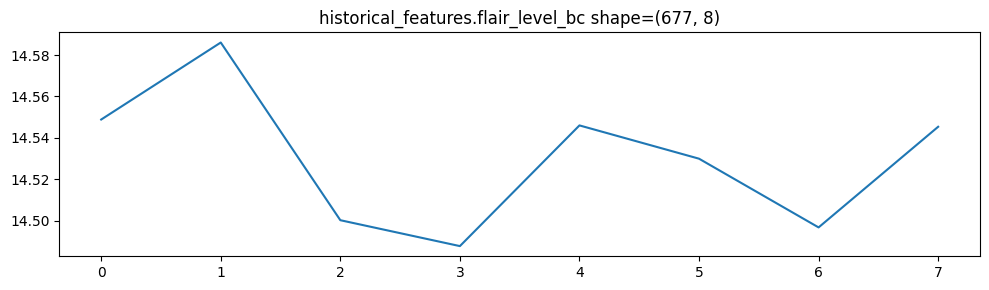

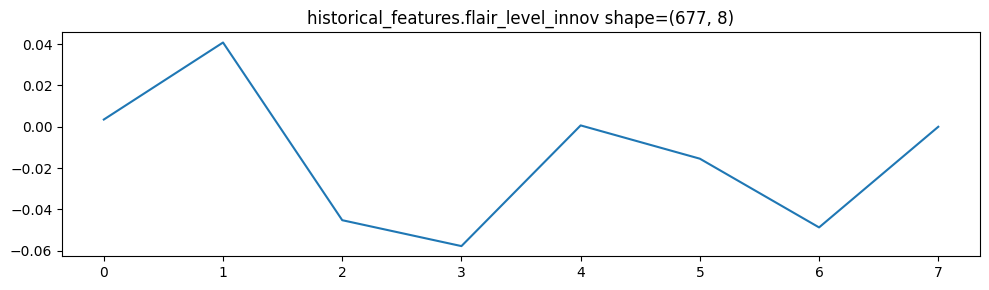

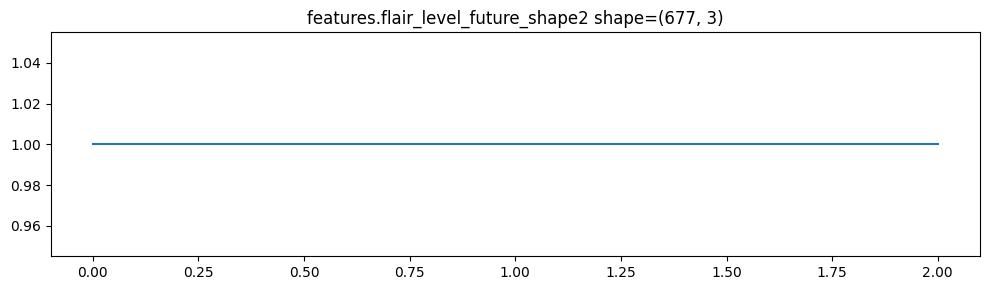

FLAIR Ridge levels: 100%|██████████| 677/677 [00:00<00:00, 1005.50it/s]



------------------------------------------------------------------------------
STEP 7  -  FlairRidgeLevel   [model]
  FLAIR-style soft-averaged Ridge over compressed level innovations.
  > TAKES:
      reads  flair_level_innov  (677, 8)  [historical_features]
      reads  shape_vector  (677, 336)  [historical_features]
  > IMPACT on state:
      + features: flair_point_forecast (677, 700)
      + features: flair_level_point (677, 3)
      + features: flair_level_innov_point (677, 3)
      + features: flair_ridge_beta (677, 4)
      + features: flair_ridge_residuals list
      + features: flair_ridge_phi (677,)
      + features: last_prediction (677, 700)
      + features: cumulative_prediction (677, 700)
      + features: current_residual (677, 700)
      + signal: flair_point_forecast  [forecast('sample', 'horizon') @flair_shift]
      + signal: forecast#FlairRidgeLevel  [forecast('sample', 'horizon') @flair_shift]
      + metadata: FlairRidgeLevel = {'model': 'soft_averaged_ridge', 

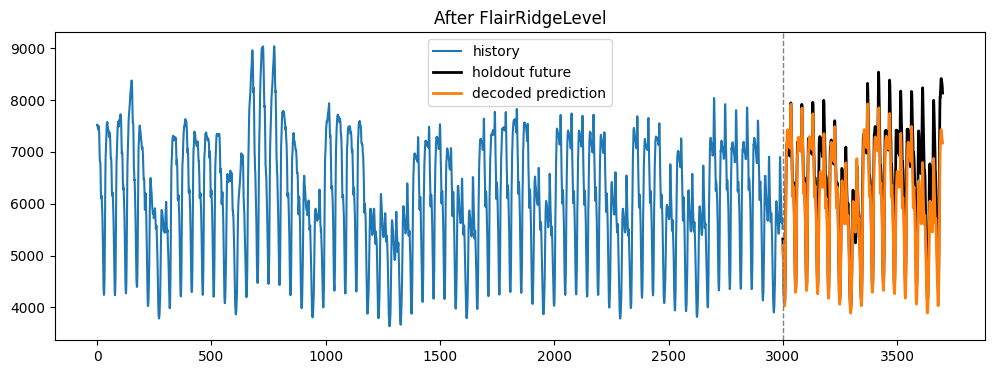

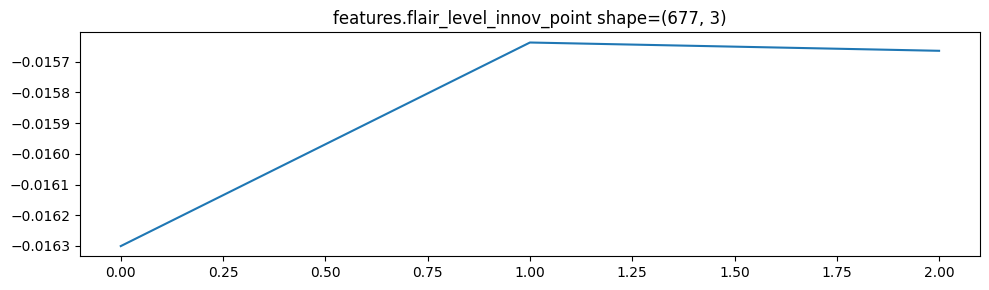

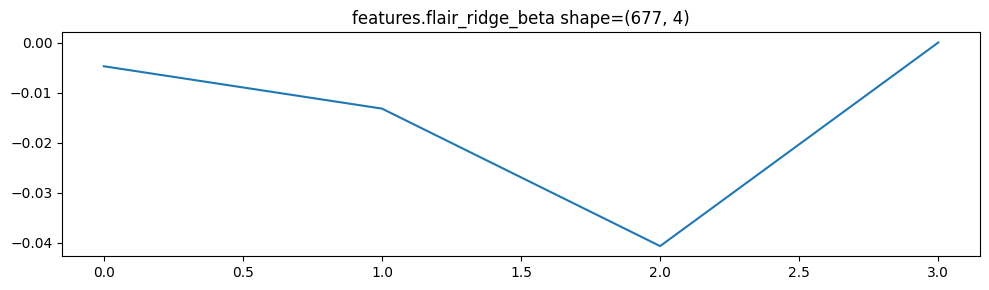

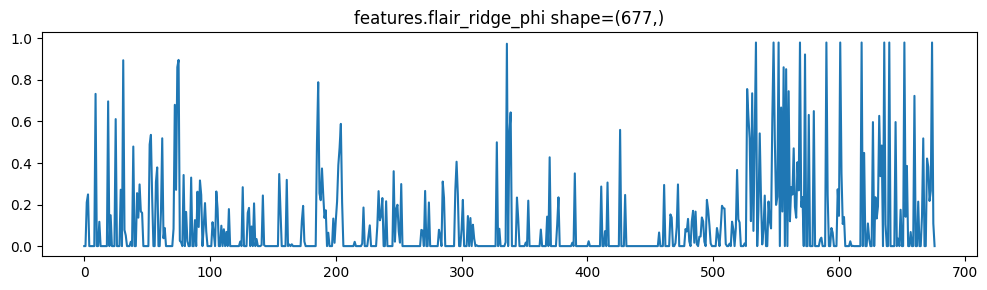

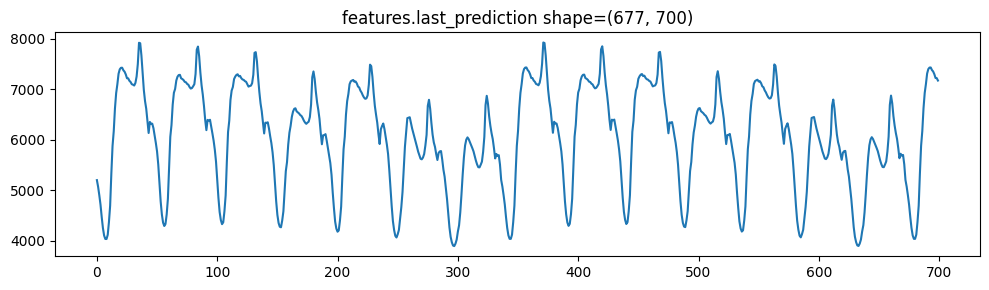

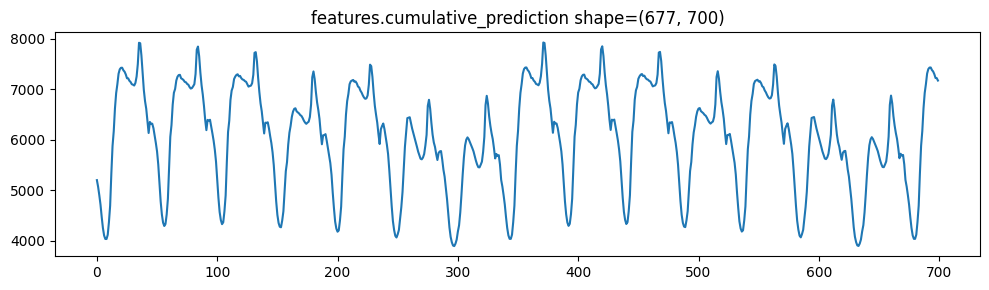

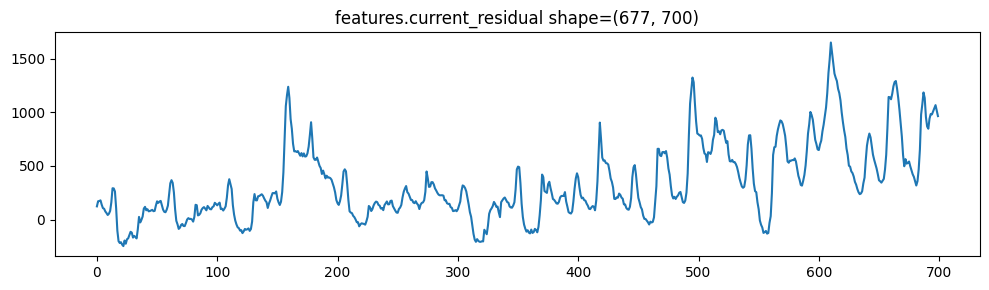


------------------------------------------------------------------------------
STEP 8  -  kernel_rbf   [model]
  RBF KernelRidge with median-heuristic lengthscale and leave-one-out predictions.
  > TAKES:
      (no declared inputs)
  > IMPACT on state:
      + signal: forecast#kernel_rbf  [forecast('sample', 'horizon') @flair_shift]
      + prediction pushed: (677, 700)   n_models 1 -> 2
      residual L2: 4.083e+09 -> 4.081e+09
  > valid next: ['kernel_rbf', 'STOP']


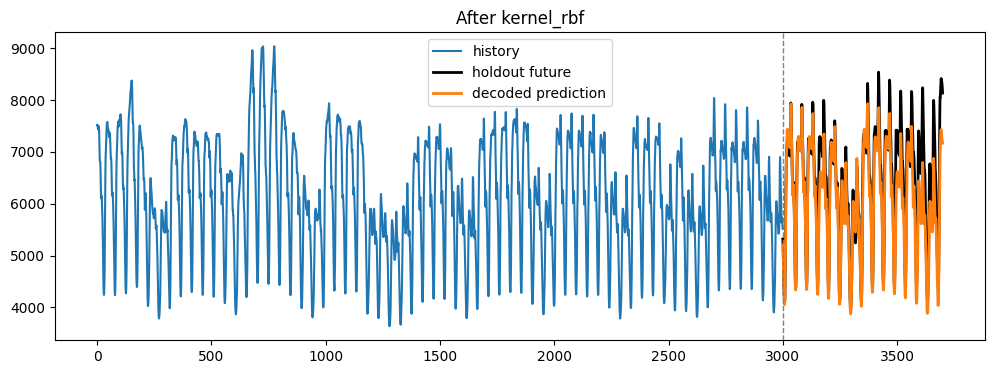

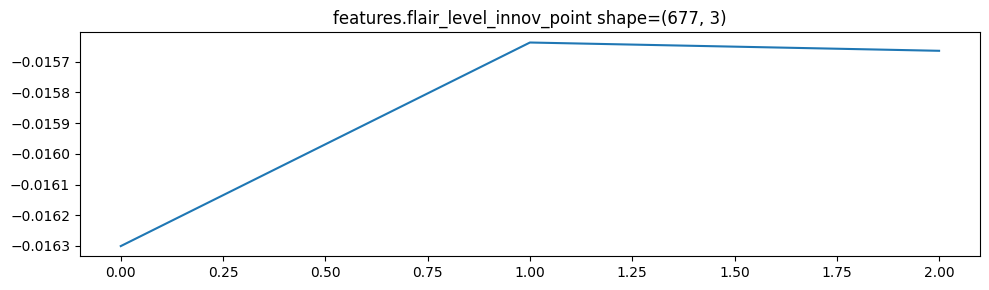

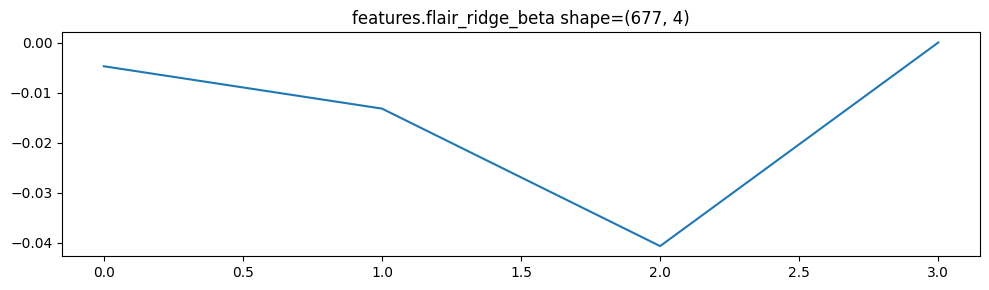

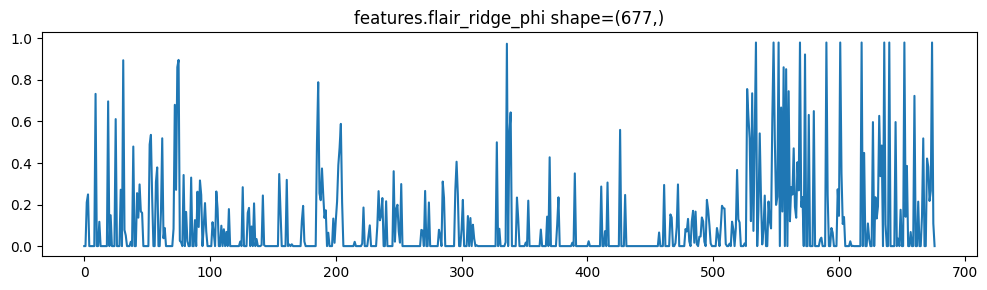

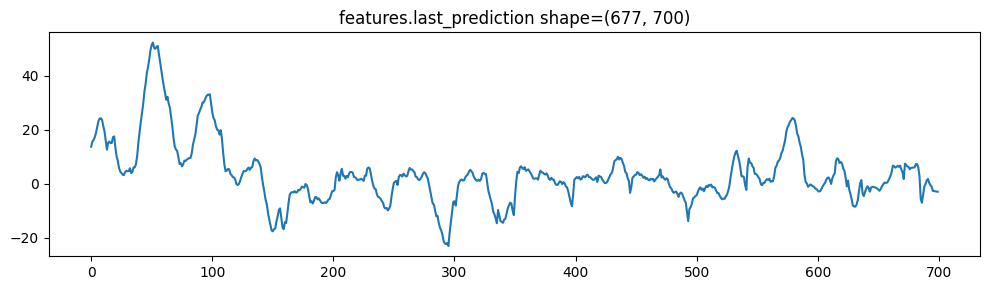

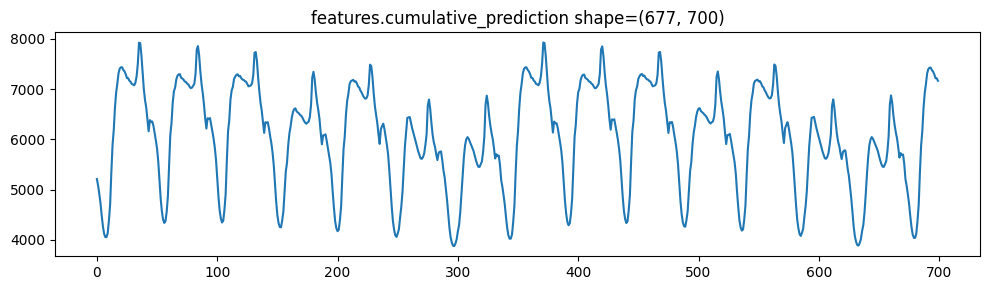

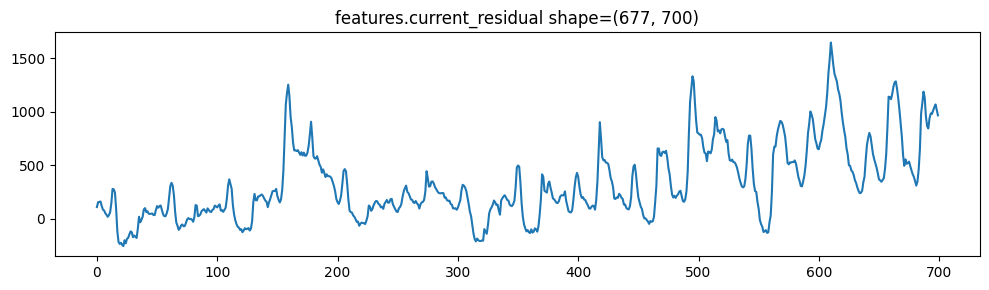


FINAL STATE
tokens: ['FlairPreprocess', 'PeriodDetect', 'PeriodFold', 'ShapeLevel', 'SecondaryLevelSeasonality', 'LevelBoxCoxCenter', 'FlairRidgeLevel', 'kernel_rbf']
current_space: flair_shift | n_models: 2
historical_features: {'flair_history': (677, 3000), 'period_matrix': (677, 336, 8), 'level_series': (677, 8), 'flair_period_matrix': (677, 336, 8), 'flair_level_raw': (677, 8), 'flair_level_denoised': (677, 8), 'shape_vector': (677, 336), 'flair_shape': (677, 336), 'flair_shape_history': (677, 336, 8), 'flair_shape2': (677, 1), 'flair_level_work': (677, 8), 'flair_level_bc': (677, 8), 'flair_level_innov': (677, 8)}
future_features: {}
metadata keys: ['FlairRidgeLevel', 'flair_boxcox', 'flair_cross_period', 'flair_cross_periods', 'flair_level_shrinkage', 'flair_secondary_periods', 'flair_shift', 'n_complete_periods', 'period', 'period_scores', 'periods', 'shape_k']
Final holdout metrics: {'mae': 151089.31772988263, 'rmse': 5928139.860799647, 'mase': 33574891.708532125, 'max_abs_err

In [14]:
state, states = inspect_pipeline(
    SEQUENCE, H, F,
    grammar=grammar,
    seasonal_period=SEASONAL_PERIOD,
    sample_idx=1,
    plot_each_step=PLOT_EACH_STEP,
    show_signal_board=SHOW_SIGNAL_BOARD,
    show_feature_bundle=SHOW_FEATURE_BUNDLE,
)


## Final forecast

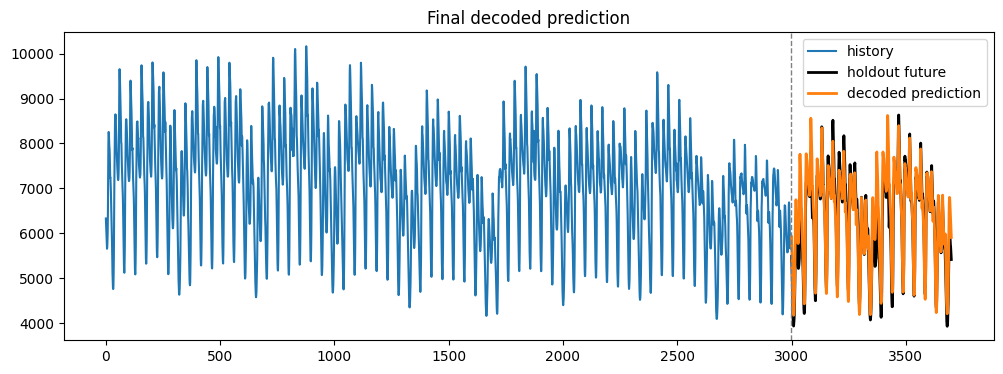

{'mae': 151089.31772988263,
 'rmse': 5928139.860799647,
 'mase': 33574891.708532125,
 'max_abs_error': 547367135.7999983}

In [13]:
plot_prediction_state(state, sample_idx= 3, title="Final decoded prediction")
score_prediction(state)

## Deep dive (optional)

`states` holds a copy after every token: `states[1]` is after the first token, `states[-1]` is final.

In [7]:
label, st = states[-1]
print("Inspecting:", label)
summarize_state(st)
display(signal_board_df(st))
display(feature_bundle_df(st))
display(artifact_df(st))


Inspecting: kernel_rbf
tokens: ['FlairPreprocess', 'PeriodDetect', 'PeriodFold', 'ShapeLevel', 'SecondaryLevelSeasonality', 'LevelBoxCoxCenter', 'FlairRidgeLevel', 'kernel_rbf']
current_space: flair_shift | n_models: 2
historical_features: {'flair_history': (677, 3000), 'period_matrix': (677, 336, 8), 'level_series': (677, 8), 'flair_period_matrix': (677, 336, 8), 'flair_level_raw': (677, 8), 'flair_level_denoised': (677, 8), 'shape_vector': (677, 336), 'flair_shape': (677, 336), 'flair_shape_history': (677, 336, 8), 'flair_shape2': (677, 1), 'flair_level_work': (677, 8), 'flair_level_bc': (677, 8), 'flair_level_innov': (677, 8)}
future_features: {}
metadata keys: ['FlairRidgeLevel', 'flair_boxcox', 'flair_cross_period', 'flair_cross_periods', 'flair_level_shrinkage', 'flair_secondary_periods', 'flair_shift', 'n_complete_periods', 'period', 'period_scores', 'periods', 'shape_k']


,name,sem,axes,alignment,space,shape,source,tags
0,raw_history,series,"(sample, time)",history,raw,"(677, 3000)",State.__init__,raw_scale
1,flair_history,series,"(sample, time)",history,flair_shift,"(677, 3000)",FlairPreprocess,"flair,preprocess"
2,param:periods,param:periods,(),static,raw,list,PeriodDetect,
3,flair_period_matrix,features,"(sample, time, feature)",history,flair_shift,"(677, 336, 8)",,
4,flair_level_raw,features,"(sample, feature)",history,flair_shift,"(677, 8)",,
5,period_matrix,series,"(sample, phase, period_idx)",history,flair_shift,"(677, 336, 8)",PeriodFold,"flair,periodic"
6,level_series,level,"(sample, period_idx)",history,flair_shift,"(677, 8)",PeriodFold,"flair,level"
7,flair_level_denoised,level,"(sample, period_idx)",history,flair_shift,"(677, 8)",PeriodFold,"denoised,flair,level"
8,flair_shape,features,"(sample, feature)",history,flair_shift,"(677, 336)",,
9,flair_shape_history,series,"(sample, time)",history,flair_shift,"(677, 336, 8)",,


feature_bundle matrix: (677, 11785) space: flair_shift


,name,sem,source,via,cols,space
0,flair_history,series,FlairPreprocess,flatten_series,3000,flair_shift
1,flair_period_matrix,features,,flatten_features,2688,flair_shift
2,flair_level_raw,features,,identity,8,flair_shift
3,period_matrix,series,PeriodFold,flatten_series,2688,flair_shift
4,level_series,level,PeriodFold,flatten_level,8,flair_shift
5,flair_level_denoised,level,PeriodFold,flatten_level,8,flair_shift
6,flair_shape,features,,identity,336,flair_shift
7,flair_shape_history,series,,flatten_series,2688,flair_shift
8,shape_vector,shape,ShapeLevel,flatten_shape,336,flair_shift
9,flair_shape2,features,,identity,1,flair_shift


,name,store,kind,shape,role,target_space,source_token,tags
0,raw_history,features,sequence,"(677, 3000)",raw_input,active_target,State.__init__,()
1,flair_history,historical_features,sequence,"(677, 3000)",clean_history,active_target,FlairPreprocess,"(flair, preprocess)"
2,period_matrix,historical_features,period_matrix,"(677, 336, 8)",feature,active_target,PeriodFold,"(flair, periodic)"
3,level_series,historical_features,level_series,"(677, 8)",feature,active_target,PeriodFold,"(flair, level)"
4,flair_period_matrix,historical_features,array,"(677, 336, 8)",feature,active_target,NaN,()
5,flair_level_raw,historical_features,array,"(677, 8)",feature,active_target,NaN,()
6,flair_level_denoised,historical_features,level_series,"(677, 8)",feature,active_target,PeriodFold,"(flair, level, denoised)"
7,shape_vector,historical_features,period_shape,"(677, 336)",feature,active_target,ShapeLevel,"(flair, shape)"
8,flair_shape,historical_features,array,"(677, 336)",feature,active_target,NaN,()
9,flair_shape_history,historical_features,array,"(677, 336, 8)",feature,active_target,NaN,()


## Token reference

In [8]:
token_table(seasonal_period=SEASONAL_PERIOD)

,token,class,learning_scope,reads,writes,description
0,FlairPreprocess,cleaning,n/a,raw_history,"flair_history, flair_shift",FLAIR preprocessing: finite interpolation plus...
1,FlairSamplePaths,feature,within_series,"flair_level_innov, shape_vector","flair_samples, flair_sample_mean",Bootstrap level residuals and coherent phase n...
2,FourierFeatures,feature,n/a,,fourier_features,Fixed low-frequency FFT features for tabular m...
3,LevelBoxCoxCenter,feature,n/a,flair_level_work,"flair_level_innov, flair_boxcox",Box-Cox transform FLAIR levels and center by t...
4,PeriodDetect,feature,n/a,raw_history,periods,FLAIR-style BIC period selection (freq candida...
5,PeriodFold,feature,n/a,"flair_history, period","period_matrix, level_series",Fold FLAIR history into period phases + level ...
6,PeriodPhaseOneHot,feature,n/a,"raw_history, period","history_period_phase_id, history_period_phase_...",One-hot encode positions within the selected p...
7,SeasonalFeatures,feature,n/a,raw_history,"seasonal_features, future_seasonal_features",Per-detected-period sin/cos channels (history ...
8,SecondaryLevelSeasonality,feature,n/a,"level_series, period","flair_shape2, flair_level_work",Estimate secondary FLAIR seasonality over peri...
9,ShapeLevel,feature,n/a,"period_matrix, level_series","shape_vector, flair_shape_history",Estimate FLAIR within-period proportions from ...
